```{note} Learning Objectives
- Understand the physical basis of magnetic permeability, electrical permittivity and electrical conductivity
- Learn how EMI instruments measure apparent electrical conductivity (ECa)
- Understand how coil orientation and spacing control depth of investigation
- Know how multi-coil multi-frequency instruments sample multiple depths simultaneously
```

---

## Physical basis

Electromagnetic (EM) survey methods are based on **Faraday's law** of induction:
a changing magnetic field induces an electromotive force (EMF) in any nearby
conductor. A time-varying magnetic field creates eddy currents in the ground,
and those currents reveal subsurface properties.

While electrical conductivity $\sigma$ (S/m) is the primary property of
interest, EM methods also depend on:

- Magnetic permeability $\mu$ — how easily a material is magnetised
  (important in magnetically susceptible soils and rocks)
- Electrical permittivity $\varepsilon$ — how much a material stores
  electrical energy (dominates at high frequencies, e.g. GPR)

At low frequencies (< 100 kHz), conductivity dominates. At high frequencies,
permittivity takes over ({cite}`boaga2017use`).

---

## Measurement principle

### From antenna to ground

A transmitter coil — a loop of wire carrying an alternating current — acts as an
antenna. The oscillating current generates a time-varying **primary magnetic field** $H_p$ that radiates into the ground.

When $H_p$ penetrates a conductive body, it induces **eddy currents** — small
loops of electrical current circulating inside the conductor. These generate a
**secondary field** $H_s$. A receiver coil detects the superposition of $H_p$
and $H_s$. Since $H_p$ is known, $H_s$ can be isolated — and it carries
information about subsurface conductivity.


```{figure} ../../assets/images/fsoil-04-1239497-g001
:name: fig-fsoilEM1
:width: 100%
:align: center
Example ECa maps from multiple coil configurations acquired simultaneously with
a multi-coil EMI instrument. From {cite}`mclachlan2021emagpy`.
```


### Apparent electrical conductivity

Under the **low induction number (LIN)** assumption — valid when the
coil spacing $s \ll$ skin depth — the apparent electrical conductivity
ECa (mS/m) is:

$$ECa = \frac{4}{\omega \mu_0 s^2} \cdot \text{Im}\!\left(\frac{H_s}{H_p}\right)$$

where $\omega = 2\pi f$ is the angular frequency and $\mu_0$ the
magnetic permeability of free space.

:::{note}
The low induction number approximation breaks down in highly conductive
soils (ECa > ~100 mS/m). Full solution inversion should be used in those cases.
:::

---

## Multi-coil and multi-frequency instruments

A single transmitter–receiver pair at one frequency and one spacing yields a
single ECa value — a depth-weighted average of conductivity over a broad volume.
To recover a **conductivity depth profile**, modern frequency-domain EM (FDEM) instruments
combine multiple configurations simultaneously:

- **Multiple coil spacings** $s_1, s_2, \dots$ — larger spacing → deeper
  depth of investigation
- **Multiple frequencies** $f_1, f_2, \dots$ — lower frequency → deeper
  skin depth → greater penetration

Each combination yields one ECa value at a different effective depth, giving a
set of independent measurements per location that can be jointly inverted for a
conductivity depth profile.


```{figure} ../../assets/images/fsoil-04-1239497-g002
:name: fig-fsoilEM2
:width: 100%
:align: center
EMI measurement principle — primary field $H_p$, induced eddy currents, and
secondary field $H_s$. From {cite}`mclachlan2021emagpy`.
```



<!--
```{figure} ../../assets/images/placeholder_multicoil_depth.png
:name: fig-multicoil-depth
:width: 75%
:align: center
Cumulative sensitivity curves for multiple coil spacings in HCP mode — increasing
spacing extends the depth of investigation. *[figure to add]*
```
-->

---

## Coil orientations

Two standard configurations are used, each with a different **depth sensitivity**
profile (McNeill, 1980):

- **HCP — Horizontal Coplanar** (coils flat, vertical magnetic dipole):
  deeper sensitivity, peaks below the surface — reaches ~ $0.75\,s$
- **VCP — Vertical Coplanar** (coils upright, horizontal magnetic dipole):
  shallower, stronger near-surface response — reaches ~ $0.5\,s$

<!--
```{figure} ../../assets/images/placeholder_coil_geometry.png
:name: fig-coil-geometry
:width: 70%
:align: center
HCP and VCP coil configurations with their respective magnetic dipole
orientations. *[figure to add]*
```
-->

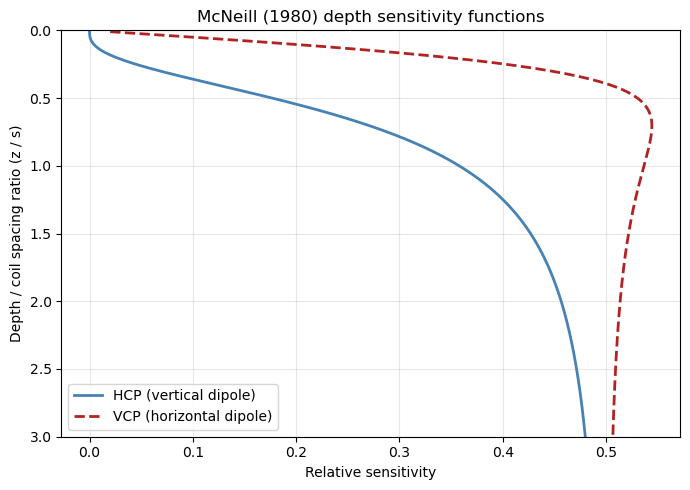

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sensitivity_HCP(z, s=1.0):
    return (4*z**3) / (4*z**2 + s**2)**1.5

def sensitivity_VCP(z, s=1.0):
    return (2*z) / (4*z**2 + s**2)**0.5 - (4*z**3) / (4*z**2 + s**2)**1.5

z = np.linspace(0.01, 3, 300)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(sensitivity_HCP(z), z, label='HCP (vertical dipole)', color='steelblue', linewidth=2)
ax.plot(sensitivity_VCP(z), z, label='VCP (horizontal dipole)', color='firebrick', linewidth=2, linestyle='--')
ax.set_xlabel("Relative sensitivity")
ax.set_ylabel("Depth / coil spacing ratio (z / s)")
ax.set_ylim(3, 0)
ax.set_title("McNeill (1980) depth sensitivity functions")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()